In [1]:
# import openkarst
import pykasso as pk
import importlib
importlib.reload(pk)
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import networkx as nx
import openkarst.models
importlib.reload(openkarst.models)
import openkarst.io.cave_data_loader as cdl
importlib.reload(cdl)
import seaborn as sns
import openpnm as op
import contextily as cx
import geopandas as gpd
import pickle
import json
from openkarst.network_generation import compute_conduit_lengths
from openkarst.visualization.animation_pyvista import animate_network
from openkarst.models import FlowSimulation
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../src"))) #use this to be able to import local packages


In [2]:
import utils.config as config
importlib.reload(config)
import utils.common as common
importlib.reload(common)
from utils.common import *
from utils.config import * 
from utils.calibration import *
from utils.conduits import *
from utils.geos import *
import scripts.openkarst.run_openkarst as ok
import utils.openkarst_network
importlib.reload(utils.openkarst_network)
importlib.reload(ok)
import utils.linear_reservoir as lr
importlib.reload(lr)


<module 'utils.linear_reservoir' from 'c:\\Users\\huan1428\\Documents\\karst\\UMNBearSpring\\src\\utils\\linear_reservoir.py'>

# Load Network

In [48]:
network_name = "branching_straight_network"
network_dir = f'conduit_geometry_test/networks/{network_name}'
network = ok.load_network_data(f'{network_dir}/nodes.csv', f'{network_dir}/edges.csv', debug= True)
network.extract_diffuse_inlets()
network.plot_3D_network(node_color = 'type')

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126]


# Load and Write Recharge

In [ ]:
#just a box injection for 1 day

baseflow = 0.02  #m3/s
peakflow = baseflow * 10
duration = 24 * 3600 # seconds
dt = 3600 #seconds
t = np.arange(0, 24*20*3600, dt) # in seconds
def gaussian_recharge(t, peak, center, duration):
    """
    t        : time array
    peak    : max recharge value
    center  : time of peak
    duration: FWHM (event duration)
    """

    sigma = duration / 2.355

    return peak * np.exp(-(t-center)**2 / (2*sigma**2))

gauss_R  = (gaussian_recharge(t, peakflow - baseflow, 24*10*3600, duration) + baseflow) * 86400 # m3/d


In [36]:
gauss_R_dict = {'flow' : gauss_R, 'time' : t}
write_pickle( f'input_data/gaussian_recharge.pkl', gauss_R_dict)

<Axes: >

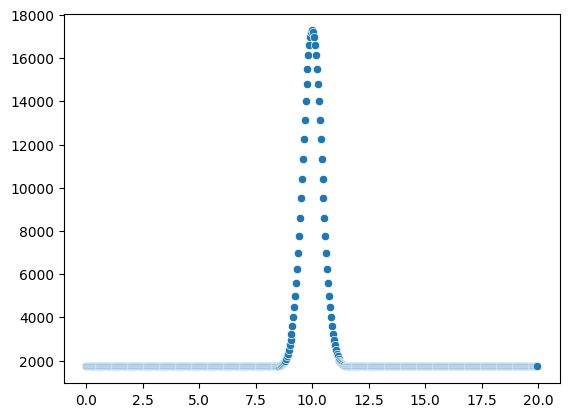

In [59]:
sns.scatterplot(y = gauss_R, x = t/86400)

In [60]:
A = 4629284 #springshed area 
n =.01 #effective porosity
d = 10 # m 
V_l = A * d * n#m^3
S_max = .3 #m
S_0 = 0.3
k = 1 #1 / d 
eta = 0.3
alpha_l = 0.1 #1 /d 
alpha_h = 0.5 #1 /d 

In [67]:
n_days = 30
# steady_state_R = np.ones(n_days) * baseflow / A * 86400 # m / d 
steady_state_R = np.ones(n_days) * baseflow * 86400 # m3 / d
steady_state_t = np.arange(0, n_days)

In [248]:
ss_R_df = pd.DataFrame({'R [m3/d]' : steady_state_R, 'T [d]' : steady_state_t})
ss_R_df.to_csv('conduit_geometry_test/input_data/baseflow.csv', index = False)

In [7]:
ss = lr.linear_reservoir_model(steady_state_R * (1-eta), steady_state_R * eta, steady_state_t, alpha_l = alpha_l, alpha_h = alpha_h, V_l0 = 0, dt_unit = 'D')
# ss = lr.full_model(steady_state_R , np.zeros(n_days), steady_state_t/86400, A = A, eta = eta, V_l = V_l, S_max = S_max, S_0 = S_0, k = k, n_l = eta, alpha_l = alpha_l, alpha_h = alpha_h, dt_unit = 'D')

No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time object

<Axes: xlabel='date', ylabel='Q_l [V/T]'>

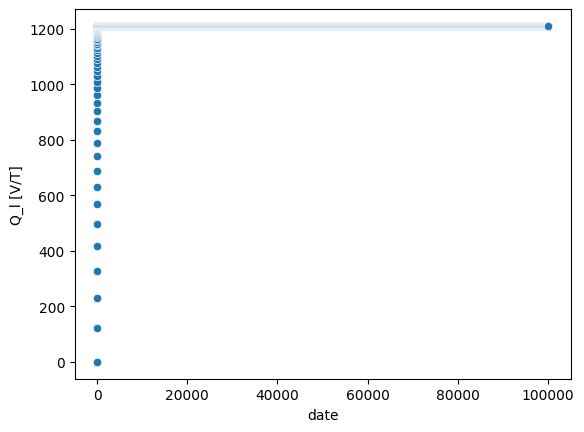

In [8]:
sns.scatterplot(ss, x = 'date', y = 'Q_l [V/T]')

In [61]:
V_l0 = ss['V_l [V]'].iloc[-1] #initial V_l 
pulse = lr.linear_reservoir_model(gauss_R * (1-eta), gauss_R * eta, t / 86400, alpha_l = alpha_l, alpha_h = alpha_h, V_l0 = V_l0, dt_unit = 'D')


No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time objects given, make sure t is in correct units: D
No time object

Text(0.5, 1.0, 'Linear reservoir recharge partitioning')

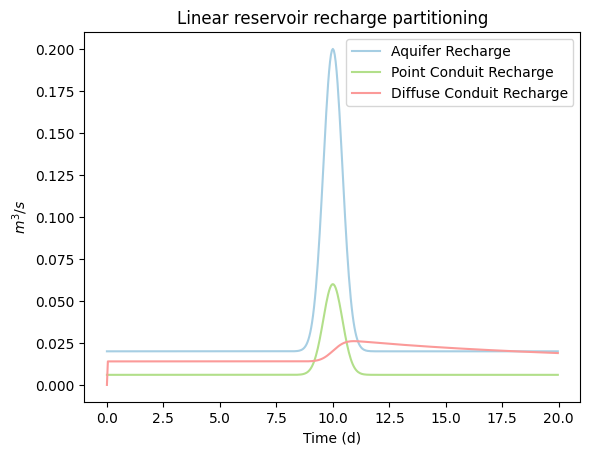

In [274]:
colors = {
    'precip':  '#A6CEE3',   # pastel blue
    'R_L':     '#FDBF6F',   # pastel orange
    'R_H':     '#B2DF8A',   # pastel green
    'Q_L':     '#FB9A99',   # pastel coral/red
    'Q_H':     '#CAB2D6',   # pastel purple
    'modeled': '#80CDC1',   # pastel teal
    'observed':'#5DA5DA'    # pastel navy
}

sns.lineplot(x =pulse.date, y =  pulse['R_l [V/T]']/86400 + pulse['R_h [V/T]']/86400, color = colors['precip'], label = 'Aquifer Recharge')

sns.lineplot(pulse, x = 'date', y = pulse['R_h [V/T]']/86400, label = 'Point Conduit Recharge', color = colors['R_H'])
sns.lineplot(pulse, x = 'date', y = pulse['Q_l [V/T]']/86400, label = 'Diffuse Conduit Recharge', color = colors['Q_L'])

# sns.lineplot(x = , y =, label = "Aquifer Recharge")
plt.xlabel("Time (d)")
plt.ylabel(r"$m^3/s$")
plt.title("Linear reservoir recharge partitioning")
# sns.lineplot(ss, x = 'date', y = 'R_h [L/T]')

In [64]:
pulse.to_csv('conduit_geometry_test/input_data/gaussian_pulse.csv', index = False)

In [37]:
def write_recharge(network, R_l=None, R_h=None, t_l=None, t_h=None):
    R = {}
    if R_l is not None: 
        if t_l is None:
             return ValueError("Time is None")
        n_diffuse = len(network.diffuse_inlets)
        R_l_per_inlet = R_l / n_diffuse 
        R[network.diffuse_inlets] = {'flow' : R_l_per_inlet, 'time' : t_l}
    if R_h is not None:
        if t_h is None:
            return ValueError("Time is None")
        n_point = len(network.inlets)
        R_h_per_inlet = R_h / n_point 
        R[network.inlets] = {'flow' : R_h_per_inlet, 'time' : t_h}
    return R

def write_constant_head_boundary(network, h):
    HB = {network.outlets : {'head' : h}}
    return HB 


In [38]:
pulse = pd.read_csv("conduit_geometry_test/input_data/gaussian_pulse.csv")

In [39]:
network.plot_3D_network()

In [49]:
#diffuse-only 
R_gauss = write_recharge(network, R_l =pulse['Q_l [V/T]']/86400 +  pulse['R_h [V/T]']/86400,  t_l = pulse['date'] * 86400)
write_pickle(f'conduit_geometry_test/input_data/inflow_boundary/{network_name}_diffuse_only.pkl', R_gauss)

In [50]:
#point-only
R_gauss = write_recharge(network, R_h =pulse['Q_l [V/T]']/86400 +  pulse['R_h [V/T]']/86400,  t_h = pulse['date'] * 86400)
write_pickle(f'conduit_geometry_test/input_data/inflow_boundary/{network_name}_point_only.pkl', R_gauss)

In [251]:
R_ss = write_recharge(network, R_l = steady_state_R/86400, t_l = steady_state_t * 86400)
write_pickle(f'conduit_geometry_test/input_data/{network_name}_ss/inflow_boundary.pkl', R_ss)

In [250]:
HB = write_constant_head_boundary(network, 0.01)
write_pickle(f'conduit_geometry_test/input_data/{network_name}_ss/head_boundary.pkl', HB)


## Load Steady State and Write Initial Conditions in Network

In [4]:
def get_outlet_Q(Q, outflow_node_ids, edges):
    outlets ={}
    for node in outflow_node_ids:
        edges_loc = edges[(edges.to_id == node) | (edges.from_id == node)].index
        outlet_Q = 0
        for edge in edges_loc:
            outlet_Q += Q[:, edge]
        outlets[node] = outlet_Q
    return outlets

In [5]:
ss_out = np.load(f'conduit_geometry_test/output/{network_name}_spin_up/results_arrays.npz')
# input_data = load_pickle(f'conduit_geometry_test/output/{network_name}_spin_up/input_data.pkl')
Q = ss_out['Q']
y = ss_out['y']
t = ss_out['t']
spring = get_outlet_Q(Q, network.outlets, network.edges)


<Axes: >

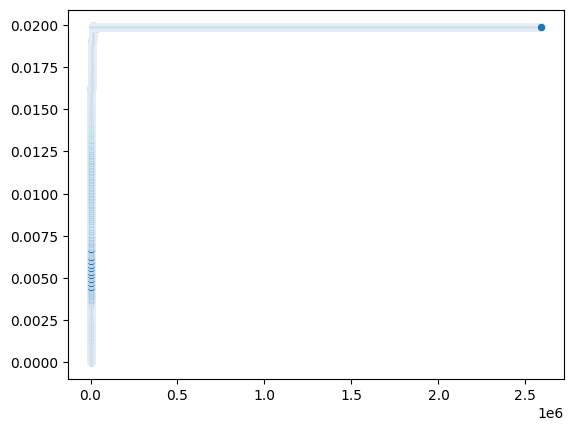

In [279]:
sns.scatterplot(y = spring[network.outlets[0]], x= t)

In [7]:
init_Q = Q[len(t) - 1]
init_h = y[len(t) - 1]


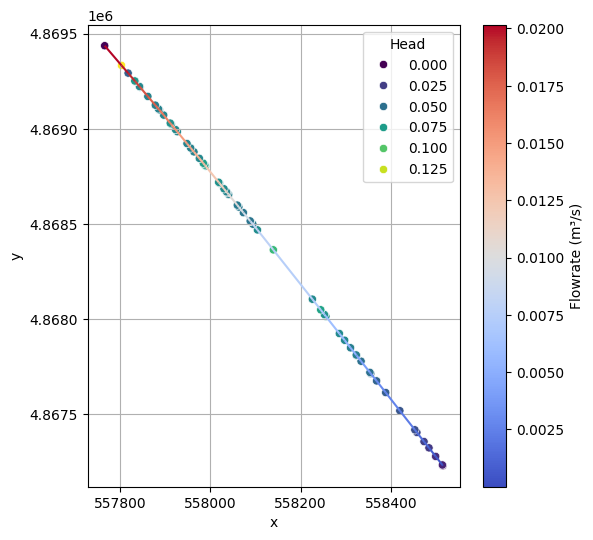

In [9]:
network.plot_network_flow(init_Q, init_h, axes = ('x', 'y'))

In [282]:
init_cond = {'initial_flowrate' : init_Q, 'initial_water_depth' : init_h}
write_pickle(f"conduit_geometry_test/input_data/init_conditions/{network_name}_IC.pkl", init_cond)

# Load Transient Results

In [59]:
run_name = 'straight_conduit_n62_gauss'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/{run_name}.yaml')
run_network = input['network_dir']
network = ok.load_network_data(f'conduit_geometry_test/{run_network}/nodes.csv', f'conduit_geometry_test/{run_network}/edges.csv')
network.extract_diffuse_inlets()
r = load_pickle(f'conduit_geometry_test/{input['inflow_file']}')
Q = results['Q']
y = results['y']
sc_t = results['t']
sc_spring = get_outlet_Q(Q, network.outlets, network.edges)



(1.0, 26.249882419815833)

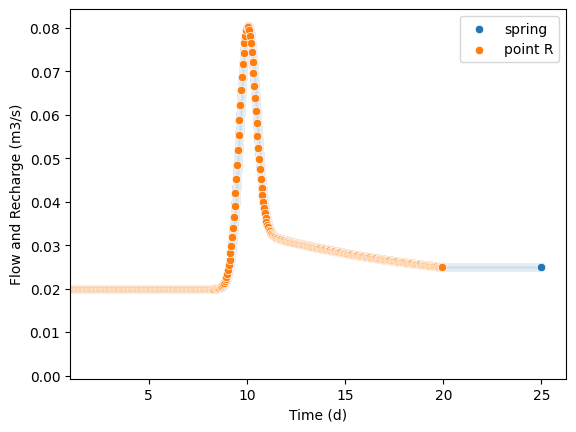

In [52]:
for node, Q_spring in sc_spring.items():
    sns.scatterplot(x = sc_t/86400, y = Q_spring, label = 'spring')

for nodes, r_i in r.items():
    sns.scatterplot(x = r_i['time']/86400, y = r_i['flow'] * len(nodes), label = 'diffuse R' if len(nodes) > 1 else 'point R')

plt.ylabel('Flow and Recharge (m3/s)')
plt.xlabel("Time (d)")
plt.xlim(1,)

In [58]:
run_name = 'pykasso_n58_gauss'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/{run_name}.yaml')
run_network = input['network_dir']
network = ok.load_network_data(f'conduit_geometry_test/{run_network}/nodes.csv', f'conduit_geometry_test/{run_network}/edges.csv')
network.extract_diffuse_inlets()
r = load_pickle(f'conduit_geometry_test/{input['inflow_file']}')
Q = results['Q']
y = results['y']
pk_t = results['t']
pk_spring = get_outlet_Q(Q, network.outlets, network.edges)

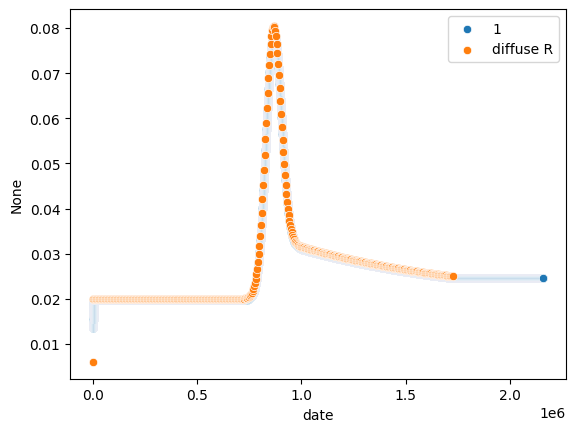

In [55]:
for node, Q_spring in pk_spring.items():
    sns.scatterplot(x = pk_t, y = Q_spring, label = node)

for nodes, r_i in r.items():
    sns.scatterplot(x = r_i['time'], y = r_i['flow'] * len(nodes), label = 'diffuse R' if len(nodes) > 1 else 'point R')

In [64]:
run_name = 'branching_straight_network_gauss'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/{run_name}.yaml')
run_network = input['network_dir']
network = ok.load_network_data(f'conduit_geometry_test/{run_network}/nodes.csv', f'conduit_geometry_test/{run_network}/edges.csv')
network.extract_diffuse_inlets()
r = load_pickle(f'conduit_geometry_test/{input['inflow_file']}')
Q = results['Q']
y = results['y']
b_t = results['t']
b_spring = get_outlet_Q(Q, network.outlets, network.edges)



In [69]:
Q.shape

(215999, 126)

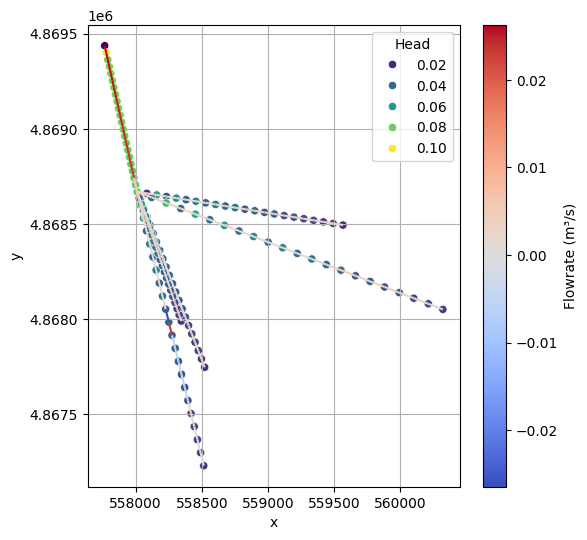

In [73]:
network.plot_network_flow(Q[150000, :], y[150000, :])

(0.02, 0.08429906617538094)

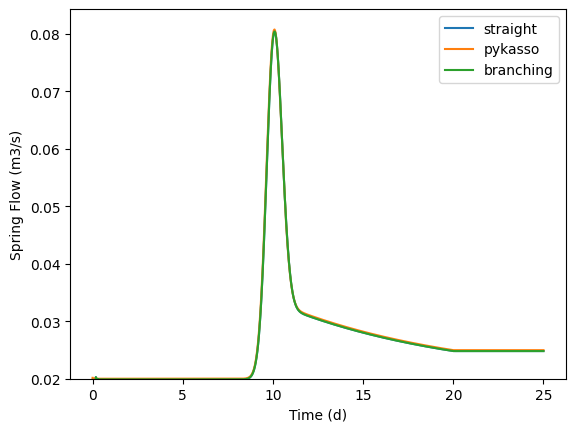

In [66]:
for name, spring in {"straight" : sc_spring, "pykasso" : pk_spring, "branching" : b_spring}.items():
    for node, Q_spring in spring.items():
        sns.lineplot(x = pk_t/86400 if name == 'pykasso' else sc_t/86400 if name == 'straight' else b_t/86400 , y = Q_spring, label = name)
plt.xlabel("Time (d)")
plt.ylabel("Spring Flow (m3/s)")
plt.ylim(0.02,)
# for nodes, r_i in r.items():
#     sns.lineplot(x = r_i['time'], y = r_i['flow'] * len(nodes), label = 'diffuse R' if len(nodes) > 1 else 'point R')


## Compare Recharge Conditions

In [ ]:
run_name = 'straight_conduit_n62_gauss'
results = np.load(f'conduit_geometry_test/output/{run_name}/results_arrays.npz')
input = load_yaml(f'conduit_geometry_test/{run_name}.yaml')
run_network = input['network_dir']
network = ok.load_network_data(f'conduit_geometry_test/{run_network}/nodes.csv', f'conduit_geometry_test/{run_network}/edges.csv')
network.extract_diffuse_inlets()
r = load_pickle(f'conduit_geometry_test/{input['inflow_file']}')
Q = results['Q']
y = results['y']
sc_t = results['t']
sc_spring = get_outlet_Q(Q, network.outlets, network.edges)

